In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#read data
df = pd.read_csv("/home/msft.us.txt")

In [4]:
#drop duplication values
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates()

In [5]:
#get values in the correct range
df = df[(df["Date"] >= "2009-01-01") & (df["Date"] <= "2017-12-31")].copy()


In [6]:
#integrity checks
print("Nulls:\n", df.isna().sum())
print("Duplicates:", df.duplicated().sum())
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Nulls:
 Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Duplicates: 0
Date range: 2009-01-02 00:00:00 to 2017-11-10 00:00:00


In [7]:
#Feature engineering
df["DailyReturn"] = df["Close"].pct_change()
df["NormalizedClose"] = df["Close"] / df["Close"].iloc[0] * 100
df["Volatility20"] = df["DailyReturn"].rolling(20).std()
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()


In [8]:
#Summary stats
summary = {
    "avg_daily_return": df["DailyReturn"].mean(),
    "volatility_daily": df["DailyReturn"].std(),
    "avg_volume": df["Volume"].mean(),
    "min_daily_return": df["DailyReturn"].min(),
    "max_daily_return": df["DailyReturn"].max(),
}
print(summary)

{'avg_daily_return': 0.0008328001889917616, 'volatility_daily': 0.01539371846004315, 'avg_volume': 51105168.37724014, 'min_daily_return': -0.11705335712966947, 'max_daily_return': 0.10511721704058496}


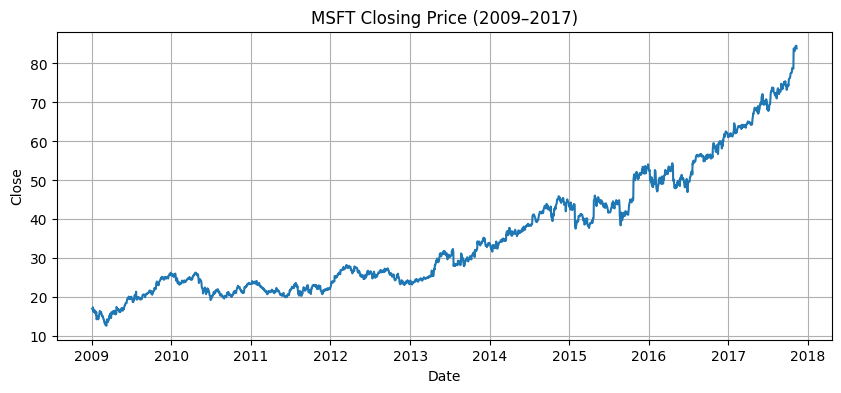

In [9]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Close"])
plt.title("MSFT Closing Price (2009–2017)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

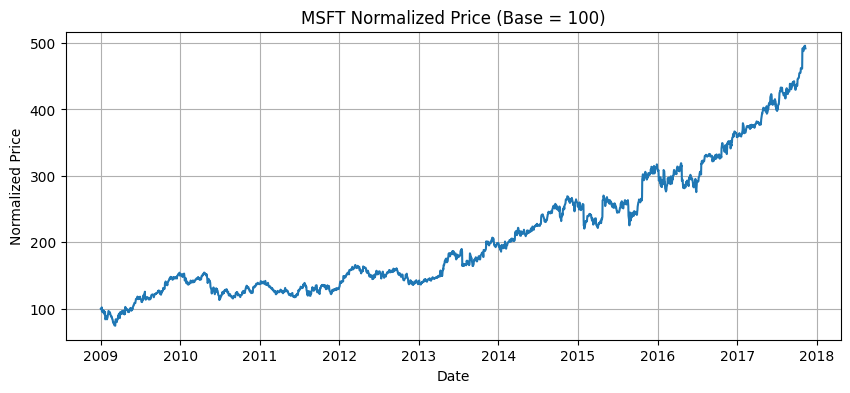

In [10]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["NormalizedClose"])
plt.title("MSFT Normalized Price (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(True)
plt.show()

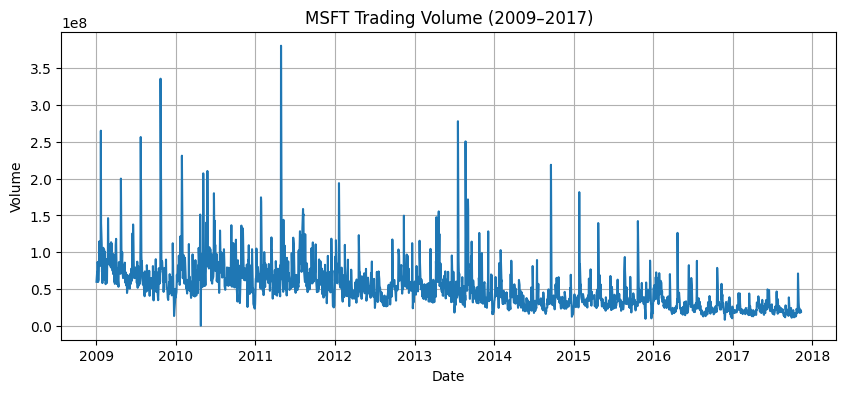

In [11]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Volume"])
plt.title("MSFT Trading Volume (2009–2017)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()


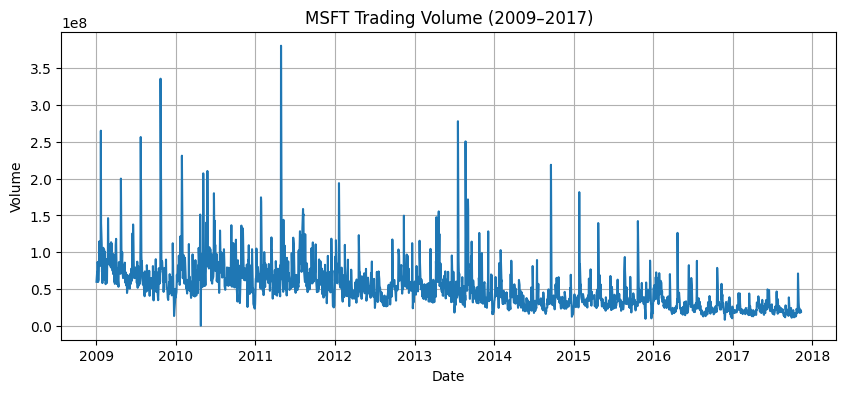

In [12]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Volume"])
plt.title("MSFT Trading Volume (2009–2017)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()


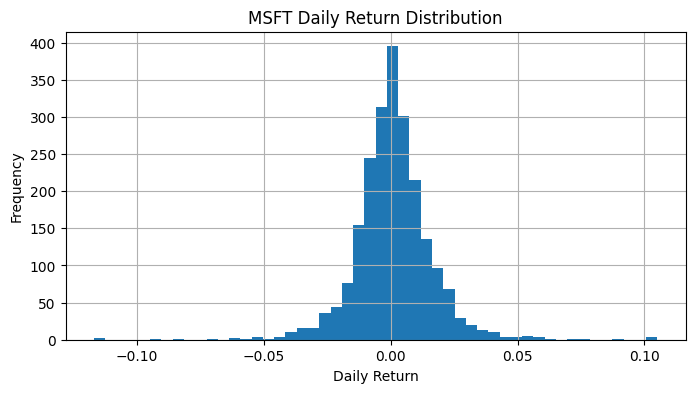

In [13]:

plt.figure(figsize=(8,4))
plt.hist(df["DailyReturn"].dropna(), bins=50)
plt.title("MSFT Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Plotting a time series of adjusted open and close price

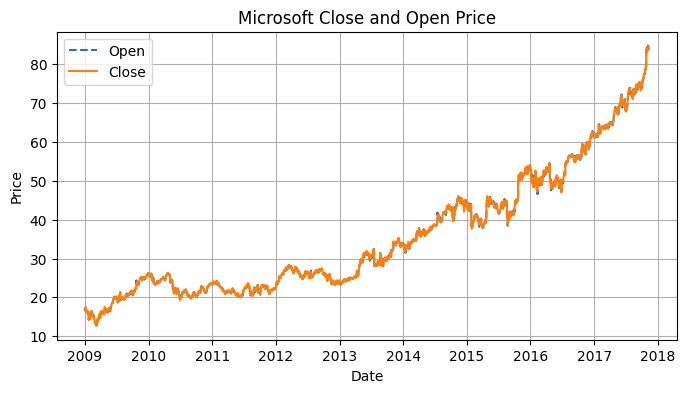

In [14]:
# Plot time series of open vs close stock price
plt.figure(figsize=(8, 4))
plt.plot(df.Date, df.Open, label='Open', linestyle='--')

plt.plot(df.Date, df.Close, label='Close', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Microsoft Close and Open Price')
plt.legend()
plt.grid()
plt.show()

The Microsoft data shows high stability. Daily fluctuations are small.

Plotting a histogram of a stock's closing price

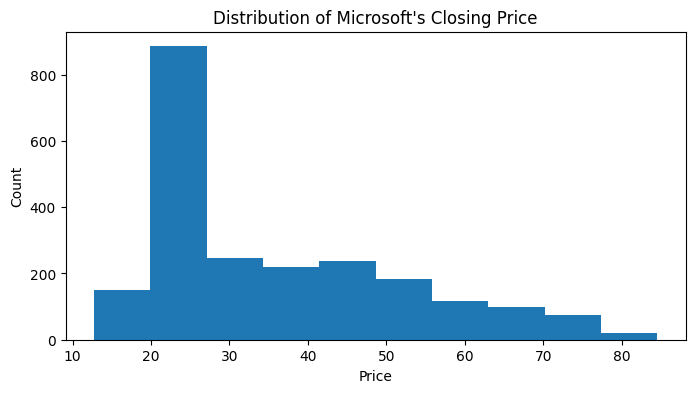

In [ ]:
# Plot the histogram of Microsoft's closing price
plt.figure(figsize=(8, 4))
plt.hist(df.Close)
plt.title("Distribution of Microsoft's Closing Price")
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


The histogram distribution confirms a positively skewed model with a strong central tendency at the lower price bound.

Plot time series of close, MA20, and MA50 stock price

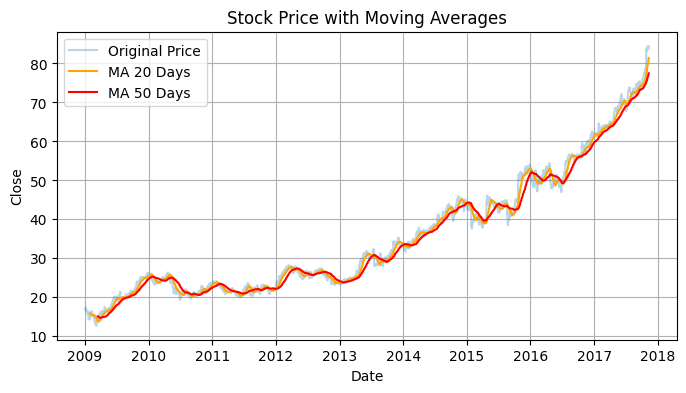

In [ ]:
# Plot time series of close, MA20, and MA50 stock price
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x=df['Date'], y='Close', alpha=0.3, label='Original Price')
sns.lineplot(data=df, x=df['Date'], y='MA20', label='MA 20 Days', color='orange')
sns.lineplot(data=df, x=df['Date'], y='MA50', label='MA 50 Days', color='red')
plt.title('Stock Price with Moving Averages')
plt.legend()
plt.grid()
plt.show()


Calculating rolling volatility of a stock's price for last 3 months

Volatility is a measure of how much a stock’s returns fluctuate.
High volatility means that the stock price changes sharply, indicating higher risk. Low volatility means that the price is more stable, indicating lower risk. When calculating rolling volatility, investors can monitor how a stock’s risk changes over time, adjust their portfolios to maintain their desired risk level. A common way to calculate volatility is by using the standard deviation of returns for a stock over time.

In [ ]:
# Define the window size for the rolling calculation, 5 trading days per week
window_size = 5

In [ ]:
# Calculate rolling one-week (5-trading-day) volatility of the closing price level
# Use the max date to get the last three months of data in the dataset
df['one_week_price_volatility'] = df.Close.rolling(window_size).std()
max_date = df.Date.max()
df_last_three_months = df.loc[df['Date'] >= max_date - pd.DateOffset(months=3)]


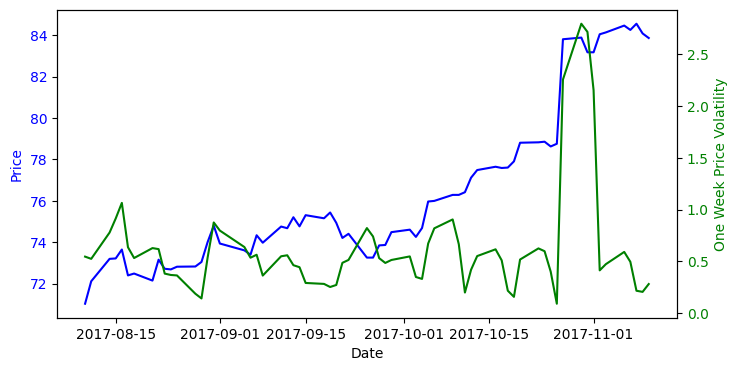

In [ ]:
# Plot the calculated rolling weekly volatility of Microsoft's closing price level against Microsoft's closing price
PRICE_COLOR = 'blue'
VOL_COLOR = 'green'
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(df_last_three_months.Date, df_last_three_months.Close, label='Price', color=PRICE_COLOR)

ax1.set_xlabel("Date")
ax1.set_ylabel("Price", color=PRICE_COLOR)
ax1.tick_params(axis="y", labelcolor=PRICE_COLOR)

ax2 = ax1.twinx()
ax2.plot(df_last_three_months.Date, df_last_three_months.one_week_price_volatility, label='Price Volatility', color=VOL_COLOR)
ax2.set_ylabel("One Week Price Volatility", color=VOL_COLOR)
ax2.tick_params(axis="y", labelcolor=VOL_COLOR)

plt.show()